## rx1day - greater newcastle + central coast

In [1]:
import glob

import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import numpy as np

from unseen import process_utils
from unseen import eva

In [2]:
#from importlib import reload

In [3]:
#reload(eva)

In [2]:
region = 'Greater Newcastle'

In [3]:
ds = xr.open_dataset('/g/data/xv83/unseen-projects/outputs/pasha/data/pr_AGCD_1900-2024_day_greater-newcastle-central-coast.nc')

In [4]:
ds

<xarray.Dataset> Size: 548kB
Dimensions:  (time: 45656)
Coordinates:
  * time     (time) datetime64[ns] 365kB 1900-01-01T09:00:00 ... 2024-12-31T0...
Data variables:
    pr       (time) float32 183kB ...
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1899-12-31T09:00:00
    date_created:              2017-01-17T22:13:51.976225
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2025-02-06 02:46:57
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2025, ...
    history:                   Thu Sep 04 13:53:35 2025: /g/data/xv83/dbi599/...

In [6]:
ds_rx1day = ds.resample(time='YE').max('time', keep_attrs=True)

In [8]:
ds_rx1day = ds_rx1day.compute()

In [15]:
ds_rx1day

<xarray.Dataset> Size: 2kB
Dimensions:  (time: 125)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1900-12-31 1901-12-31 ... 2024-12-31
Data variables:
    pr       (time) float64 1kB 50.12 43.18 80.1 75.72 ... 87.33 46.47 106.4
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1899-12-31T09:00:00
    date_created:              2017-01-17T22:13:51.976225
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2025-02-06 02:46:57
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2025, ...
    history:                   Thu Sep 04 13:53:35 2025: /g/data/xv83/dbi599/...

In [9]:
df = ds_rx1day.to_dataframe()
df.index = df.index.year

In [10]:
df

,pr
time,
1900,50.116634
1901,43.184799
1902,80.103188
1903,75.720512
1904,100.091949
...,...
2020,91.985298
2021,66.374405
2022,87.329201


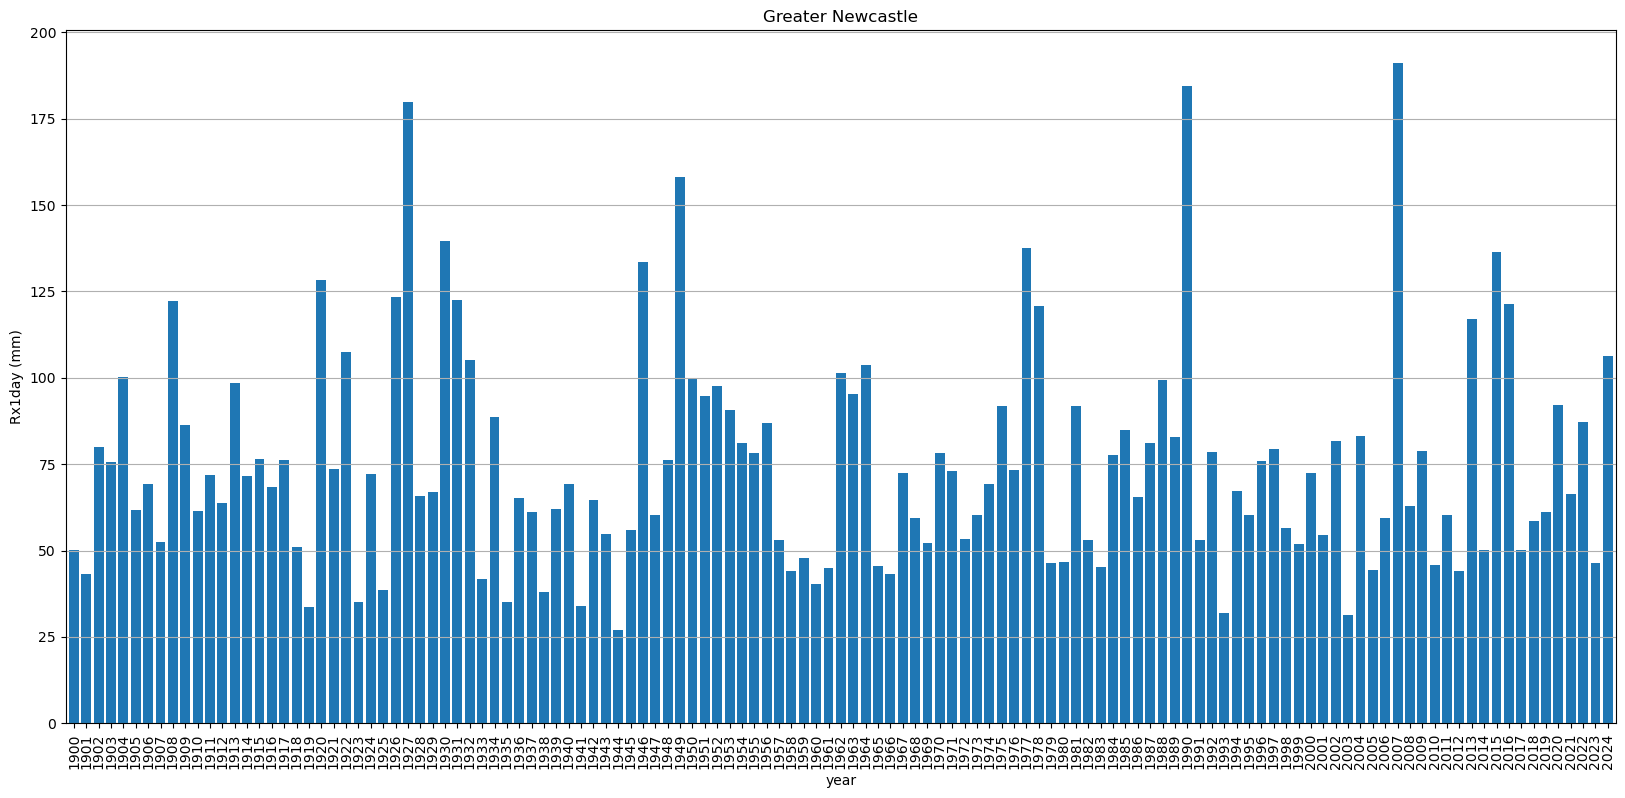

In [11]:
df['pr'].plot.bar(figsize=[20, 9], width=0.8)
plt.ylabel('Rx1day (mm)')
plt.xlabel('year')
plt.title(region)
plt.grid(axis='y')
plt.show()

In [12]:
ranked_years = df.sort_values(by='pr', ascending=False)
print(ranked_years.head(n=10))

              pr
time            
2007  191.074600
1990  184.397034
1927  179.841431
1949  158.168488
1930  139.486969
1977  137.525452
2015  136.341721
1946  133.555893
1920  128.316818
1926  123.489662


In [16]:
rx1day_2007 = float(ds_rx1day['pr'].sel(time='2007-12-31').values)
rx1day_2007

191.07460021972656

In [17]:
dparams_s = eva.fit_gev(ds_rx1day['pr'])

In [18]:
dparams_s

<xarray.DataArray 'pr' (dparams: 3)> Size: 24B
array([-0.09313673, 60.30047215, 22.07480715])
Coordinates:
  * dparams  (dparams) <U8 96B 'c' 'location' 'scale'
Attributes:
    long_name:    Genextreme parameters
    description:  Parameters of the genextreme distribution
    method:       MLE
    estimator:    LMM
    scipy_dist:   genextreme
    units:

In [20]:
dparams_ns = eva.fit_gev(
    ds_rx1day['pr'],
    stationary=False,
    covariate=ds_rx1day['time'],
    pick_best_model=True
)

/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),


In [21]:
dparams_ns

<xarray.DataArray (dparams: 5)> Size: 40B
array([-8.34358631e-02,  6.02893868e+01, -7.02037175e-06,  2.24368661e+01,
       -5.82191635e-05])
Coordinates:
  * dparams  (dparams) <U10 200B 'c' 'location_0' ... 'scale_0' 'scale_1'
Attributes:
    long_name:    Nonstationary genextreme parameters
    description:  Parameters of the nonstationary genextreme distribution
    method:       MLE
    estimator:    LMM
    scipy_dist:   genextreme
    units:

/home/599/dbi599/unseen-fork/unseen/eva.py:855: RuntimeWarning: divide by zero encountered in scalar divide
  return 1.0 / probability
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


112 year return period
95% CI: 44-1111 years


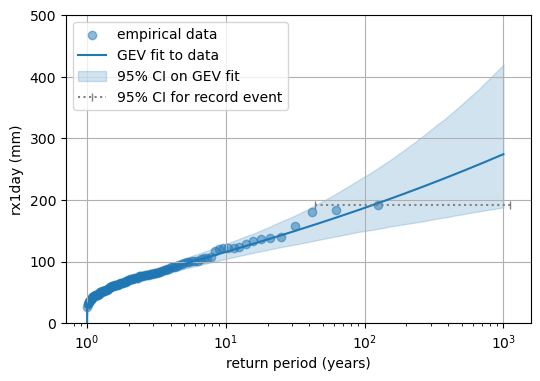

In [22]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
eva.plot_gev_return_curve(
    ax,
    ds_rx1day['pr'].values,
    rx1day_2007,
    direction="exceedance",
    bootstrap_method='parametric',
    n_bootstraps=1000,
    max_return_period=3,
    ylabel='rx1day (mm)',
    ylim=(0, 500),
)
plt.show()

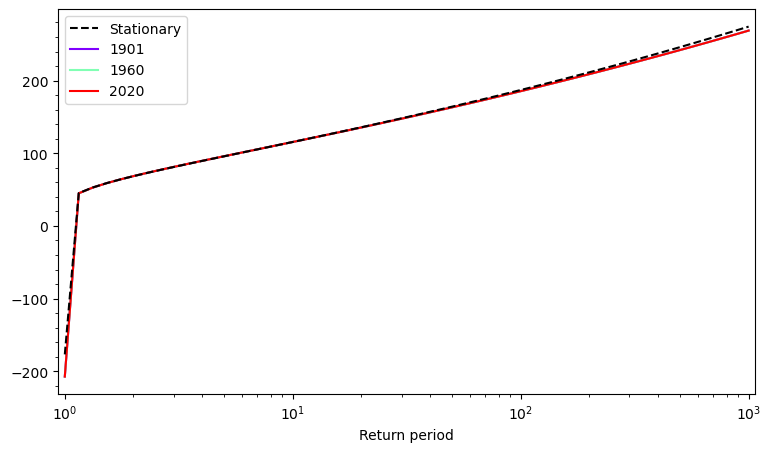

In [23]:
eva.plot_nonstationary_return_curve(
    xr.DataArray(np.logspace(0, 3)),
    dparams_s,
    dparams_ns,
    ds_rx1day['time'].isel(time=[1, 60, 120]).dt.year,
)
plt.show()

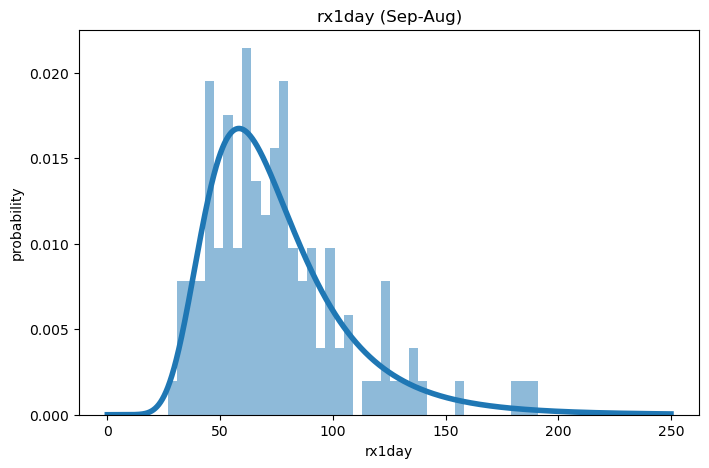

In [24]:
fig, ax = plt.subplots(figsize=[8, 5])
gev_xvals = np.arange(0, 250, 0.1)
shape, loc, scale = dparams_s

ds_rx1day['pr'].plot.hist(bins=40, density=True, color='tab:blue', alpha=0.5)
pdf = gev.pdf(gev_xvals, shape, loc, scale)
plt.plot(gev_xvals, pdf, color='tab:blue', linewidth=4.0, label='AGCD')

plt.xlabel('rx1day')
plt.ylabel('probability')
plt.title(f'rx1day (Sep-Aug)')
#plt.xlim(xmin, xmax)
plt.show()

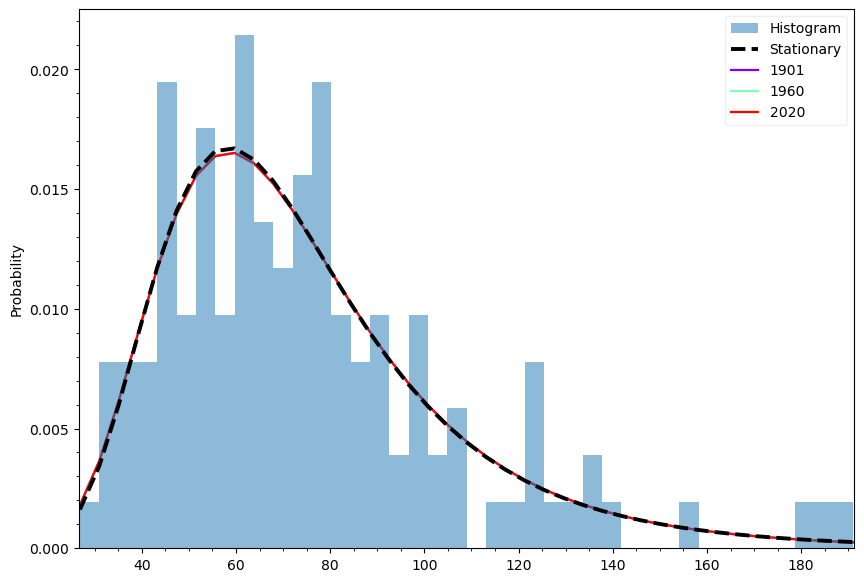

In [25]:
eva.plot_nonstationary_pdfs(
    ds_rx1day['pr'],
    dparams_s,
    dparams_ns,
    ds_rx1day['time'].isel(time=[1, 60, 120]).dt.year,
)
plt.show()